# 05. Putting All Four Methods Side by Side

One table, one plot: no-integration baseline, Harmony, scVI, scANVI. For the last three
I reuse the Leiden clusters already computed and saved in notebooks 02-04 rather than
retraining anything — no need to burn another 15 minutes per model just to read off a
number. The baseline is the one thing not computed yet: we looked at it on a UMAP back in
notebook 01, but never actually put a number on it.


In [1]:
import sys
sys.path.append("../src")

import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

sc.settings.verbosity = 1
RESOLUTIONS = [0.3, 0.5, 0.7, 1.0, 1.3]

## 1. Baseline (no integration) — computing the metrics

The same thing as the baseline UMAP in notebook 01, but now with Leiden clustering and
ARI/NMI, not just a visual impression.

In [2]:
adata_baseline = sc.read("../data/processed/pancreas_prepared.h5ad")

sc.pp.highly_variable_genes(adata_baseline, n_top_genes=2000, batch_key="tech", subset=False)
adata_baseline = adata_baseline[:, adata_baseline.var["highly_variable"]].copy()
sc.pp.scale(adata_baseline, max_value=10)
sc.tl.pca(adata_baseline, n_comps=30)
sc.pp.neighbors(adata_baseline, use_rep="X_pca")

baseline_rows = []
for res in RESOLUTIONS:
    key = f"leiden_r{res}"
    sc.tl.leiden(adata_baseline, resolution=res, flavor="igraph", n_iterations=2, directed=False, key_added=key)
    ari = adjusted_rand_score(adata_baseline.obs["celltype"], adata_baseline.obs[key])
    nmi = normalized_mutual_info_score(adata_baseline.obs["celltype"], adata_baseline.obs[key])
    baseline_rows.append({"method": "baseline (no integration)", "resolution": res, "ARI": ari, "NMI": nmi,
                           "n_clusters": adata_baseline.obs[key].nunique()})

pd.DataFrame(baseline_rows)

,method,resolution,ARI,NMI,n_clusters
0,baseline (no integration),0.3,0.427919,0.707524,19
1,baseline (no integration),0.5,0.321837,0.675942,27
2,baseline (no integration),0.7,0.318235,0.673485,29
3,baseline (no integration),1.0,0.291627,0.671243,32
4,baseline (no integration),1.3,0.288296,0.668877,34


## 2. Harmony / scVI / scANVI — recomputing ARI/NMI from the already-saved Leiden clusters

The files `pancreas_harmony.h5ad`, `pancreas_scvi.h5ad`, `pancreas_scanvi.h5ad` already
contain `leiden_r0.3`, `leiden_r0.5`, etc. columns from their respective notebooks — we
just read them and compute metrics, without retraining any models.

In [3]:
method_files = {
    "Harmony": "../data/processed/pancreas_harmony.h5ad",
    "scVI": "../data/processed/pancreas_scvi.h5ad",
    "scANVI": "../data/processed/pancreas_scanvi.h5ad",
}

all_rows = list(baseline_rows)

for method_name, path in method_files.items():
    ad = sc.read(path)
    for res in RESOLUTIONS:
        key = f"leiden_r{res}"
        if key not in ad.obs.columns:
            print(f"Skipping: {key} not found in {path}")
            continue
        ari = adjusted_rand_score(ad.obs["celltype"], ad.obs[key])
        nmi = normalized_mutual_info_score(ad.obs["celltype"], ad.obs[key])
        all_rows.append({"method": method_name, "resolution": res, "ARI": ari, "NMI": nmi,
                          "n_clusters": ad.obs[key].nunique()})

full_sweep_df = pd.DataFrame(all_rows)
full_sweep_df

,method,resolution,ARI,NMI,n_clusters
0,baseline (no integration),0.3,0.427919,0.707524,19
1,baseline (no integration),0.5,0.321837,0.675942,27
2,baseline (no integration),0.7,0.318235,0.673485,29
3,baseline (no integration),1.0,0.291627,0.671243,32
4,baseline (no integration),1.3,0.288296,0.668877,34
5,Harmony,0.3,0.914267,0.888037,12
6,Harmony,0.5,0.885303,0.867960,16
7,Harmony,0.7,0.775823,0.832568,17
8,Harmony,1.0,0.579977,0.775674,20
9,Harmony,1.3,0.465018,0.738594,24


## 3. Plot: ARI across all methods and resolutions at once

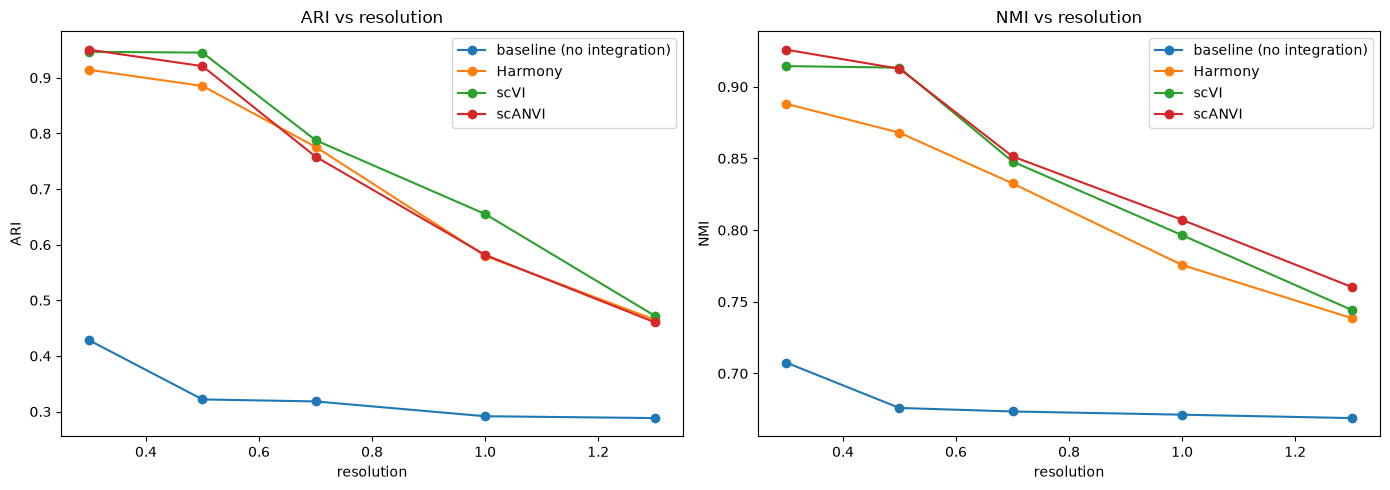

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for method_name in full_sweep_df["method"].unique():
    subset = full_sweep_df[full_sweep_df["method"] == method_name].sort_values("resolution")
    axes[0].plot(subset["resolution"], subset["ARI"], marker="o", label=method_name)
    axes[1].plot(subset["resolution"], subset["NMI"], marker="o", label=method_name)

axes[0].set_xlabel("resolution"); axes[0].set_ylabel("ARI"); axes[0].set_title("ARI vs resolution")
axes[1].set_xlabel("resolution"); axes[1].set_ylabel("NMI"); axes[1].set_title("NMI vs resolution")
axes[0].legend(); axes[1].legend()
plt.tight_layout()
plt.savefig("../results/figures/05_all_methods_sweep.png", dpi=150)
plt.show()

**What matters here**: if the baseline line sits noticeably below the other three
across the whole resolution range — that's the quantitative confirmation of what we saw
on the UMAP in notebook 01: without batch-effect correction, Leiden clusters mostly by
technology rather than biology, and this doesn't depend on the choice of resolution.

## 4. Final summary table — best result per method

In [5]:
best_per_method = (
    full_sweep_df.loc[full_sweep_df.groupby("method")["ARI"].idxmax()]
    .sort_values("ARI", ascending=False)
    .reset_index(drop=True)
)
best_per_method

,method,resolution,ARI,NMI,n_clusters
0,scANVI,0.3,0.950373,0.925812,13
1,scVI,0.3,0.946710,0.914405,11
2,Harmony,0.3,0.914267,0.888037,12
3,baseline (no integration),0.3,0.427919,0.707524,19


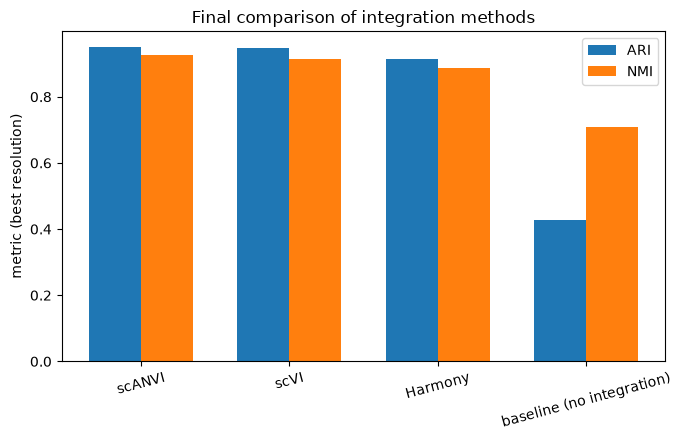

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(best_per_method))
width = 0.35
ax.bar(x - width/2, best_per_method["ARI"], width, label="ARI")
ax.bar(x + width/2, best_per_method["NMI"], width, label="NMI")
ax.set_xticks(x)
ax.set_xticklabels(best_per_method["method"], rotation=15)
ax.set_ylabel("metric (best resolution)")
ax.set_title("Final comparison of integration methods")
ax.legend()
plt.tight_layout()
plt.savefig("../results/figures/05_final_comparison.png", dpi=150)
plt.show()

## 5. Saving the summary table

In [7]:
full_sweep_df.to_csv("../results/all_methods_metrics.csv", index=False)
best_per_method.to_csv("../results/best_per_method.csv", index=False)
print("Saved to results/")

Saved to results/


## Conclusions

| Method | ARI | NMI |
|---|---|---|
| scANVI | 0.950 | 0.926 |
| scVI | 0.947 | 0.914 |
| Harmony | 0.914 | 0.888 |
| baseline (no integration) | 0.428 | 0.708 |

The main thing this table shows isn't which integration method wins — it's how much
worse everything is without integration at all. ARI roughly doubles going from baseline
to Harmony, and the three integration methods then sit fairly close together, with a
small, consistent lead for scANVI over scVI over Harmony.

The baseline's NMI (0.708) sitting well above its ARI (0.428) is worth a sentence in the
report: even uncorrected data carries real information about cell identity, it's just
scattered across many small, technology-specific clusters rather than a few clean ones
— NMI tolerates that kind of fragmentation better than ARI does.

That's the core analysis done. What's left is packaging: a proper README with the
numbers and figures, and `06_error_analysis.md` collecting the biological interpretation
from notebooks 02 and 04 in one place.